# Linear Regression with Geodesic Loss

Train a simple linear regression model on cell features using geodesic distance loss for cell cycle phase prediction.

In [1]:
import sys
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

sys.path.insert(0, "/myhome/iris")

from src.data_pipeline.dataset import (
    ModularCellFeaturesDataset,
    create_transform_pipeline_from_config,
)
from src.data_pipeline.curve_projector import FucciCurveProjector

## 1. Setup and Configuration

In [2]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Paths
h5_path = "/myhome/iris/data/fucci_3t3_221124_filtered_noNG030JP208_with_nuclei_seg.h5"
projector_path = "/myhome/iris/data/fucci_3t3_221124_filtered_noNG030JP208_with_nuclei_seg_filtered_5c7430dc.json"

# Hyperparameters
batch_size = 64
num_epochs = 500
learning_rate = 0.001
weight_decay = 0.0 #1e-4
ridge_lambda = 0.0

Using device: cuda


## 2. Load Dataset and Projector

In [3]:
from torch.utils.data import Dataset, DataLoader, random_split

# Dataset configuration
data_config = {
    "data_source": {"h5_path": h5_path, "quality_filters": {}},
    "image_transforms": [],
    # "feature_transforms": [{"class_path": "sklearn.preprocessing.StandardScaler", "init_args": {}}],
    "data_split": [0.7, 0.2, 0.1],
    "batch_size": batch_size,
    "fucci_1D_projection": True,
    "projection_shape": "polygon",
    "fucci_transform": {"log": {}},
}

log_transform_features = [
    "cell_area",
    "cell_perimeter",
    "nucleus_area",
    "nucleus_perimeter",
    "cell_major_axis_length",
    "nucleus_major_axis_length",
    "cell_minor_axis_length",
    "nucleus_minor_axis_length",
    "total_intensity_nucleus",
]

# Create dataset
print("Loading dataset...")
dataset = ModularCellFeaturesDataset(data_config=data_config, use_cache=True)

# Split into train/val/test
train_df, val_df, test_df = dataset.split_set()
# train_df = train_df.iloc[:20]

print(f"Train samples: {len(train_df)}")
print(f"Val samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

for df in [train_df, val_df, test_df]:
    for feature in log_transform_features:
        if feature in df.columns:
            df["log_" + feature] = np.log(df[feature])  # log1p to avoid log(0)

    feature_transforms = [{"class_path": "sklearn.preprocessing.StandardScaler", "init_args": {}}]
    transform_pipeline = create_transform_pipeline_from_config(feature_transforms, transform_type="feature")
    transform_pipeline.fit(df.drop(columns=dataset.label_names).to_numpy())
    df.loc[:, list(set(df.columns) - set(dataset.label_names))] = transform_pipeline.transform(df.drop(columns=dataset.label_names).to_numpy())

Loading dataset...

Creating feature transform pipeline
   - Using [] transforms

Creating image transform pipeline
   - Using [] transforms

Creating data source from: /myhome/iris/data/fucci_3t3_221124_filtered_noNG030JP208_with_nuclei_seg.h5
   ✓ Found 22,677 total cells

Applying quality filters:
   - Plane count: 3
   - Max objects: 1
   - Min segmentation pixels: 10
   - Max nuclei outside ratio: 0.2
✓ Loaded filter results from cache: /myhome/iris/data/fucci_3t3_221124_filtered_noNG030JP208_with_nuclei_seg_filtered_b52ba0fb.json

FILTERING STATISTICS
Total cells:                22,677
Valid cells:                17,982
Invalid cells:              4,695

Rejection reasons:
  - nuclei_too_large              : 2,540
  - multiple_cells                : 966
  - failed_segmentation_nuclei_segmentation: 916
  - invalid_plane_count           : 177
  - failed_segmentation_segmentation: 89
  - nuclei_outside_cell_too_large : 7

Retention rate:             79.3%
   ✓ Filtered to 17,982 val

/tmp/ipykernel_711/2663101373.py:47: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.52975911 -1.11891696 -1.10228003 ... -0.00658284 -1.17747071
 -0.88634967]' has dtype incompatible with uint64, please explicitly cast to a compatible dtype first.
  df.loc[:, list(set(df.columns) - set(dataset.label_names))] = transform_pipeline.transform(df.drop(columns=dataset.label_names).to_numpy())
/tmp/ipykernel_711/2663101373.py:47: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.35581191  1.58456561 -0.13795409 ... -0.42397714 -0.82347578
 -1.17542121]' has dtype incompatible with uint64, please explicitly cast to a compatible dtype first.
  df.loc[:, list(set(df.columns) - set(dataset.label_names))] = transform_pipeline.transform(df.drop(columns=dataset.label_names).to_numpy())
/tmp/ipykernel_711/2663101373.py:47: FutureWarning: Setting an item of

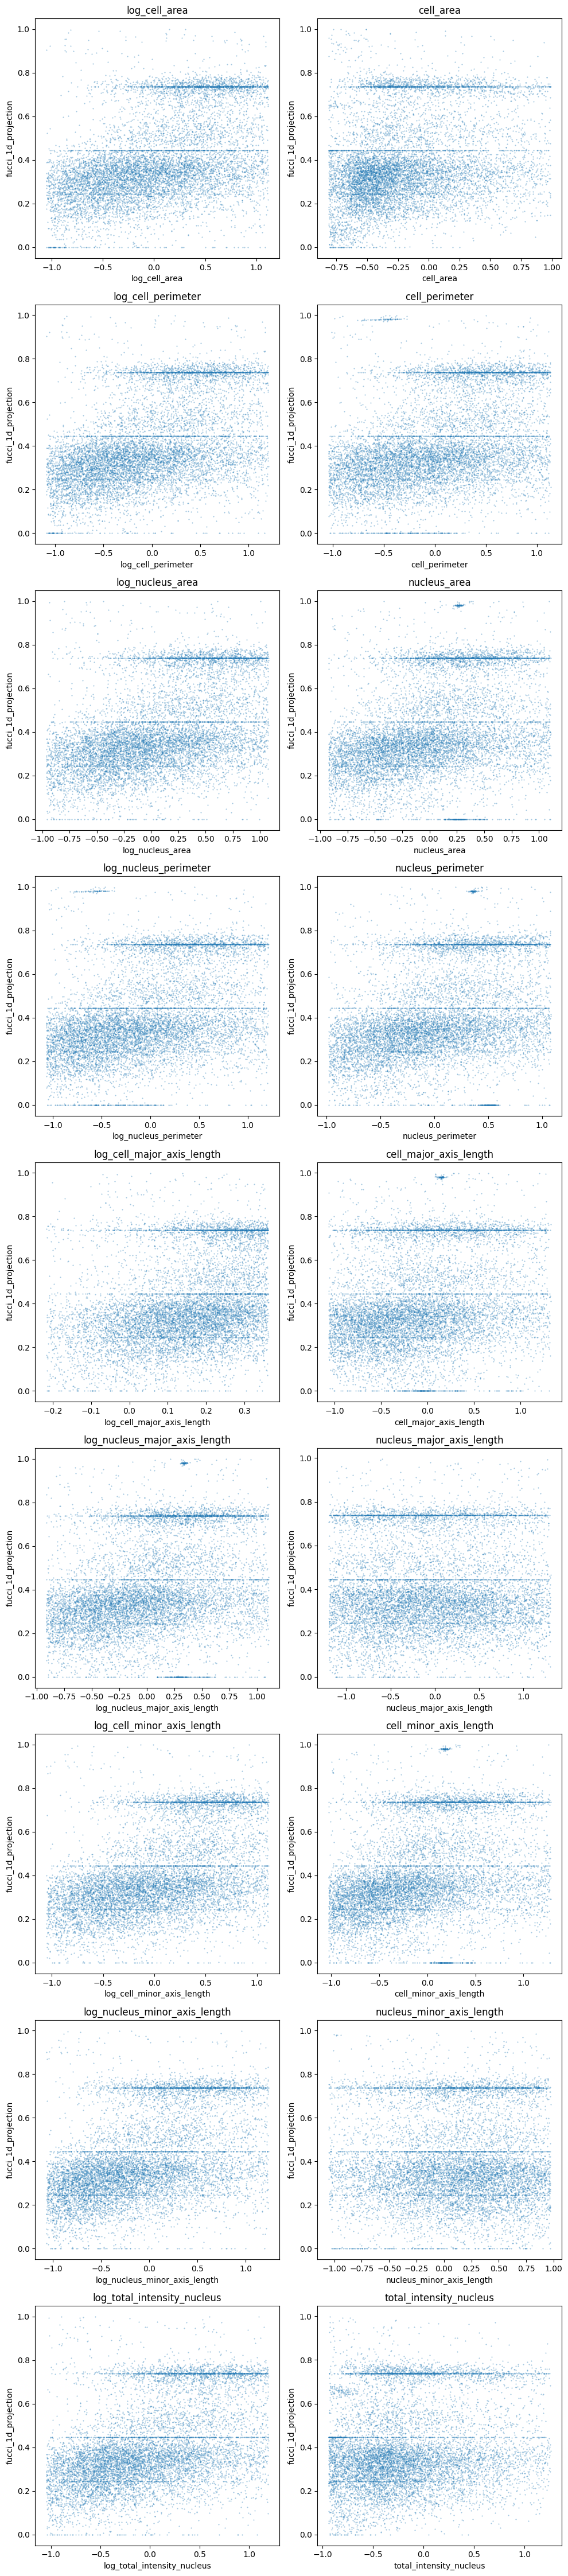

In [54]:
def quantile_mask(column, df):
    q_low = df[column].quantile(0.1)
    q_high = df[column].quantile(0.9)
    mask = (df[column] >= q_low) & (df[column] <= q_high)
    return mask

plt.figure(figsize=(10, 5*len(log_transform_features)))
for column in log_transform_features:
    log_transform_column = "log_" + column
    # Remove outliers based on quantiles
    msk = quantile_mask(log_transform_column, train_df)
    ax = plt.subplot(
        len(log_transform_features), 2, log_transform_features.index(column)*2 + 1
    )
    ax.scatter(train_df.loc[msk, log_transform_column], train_df.loc[msk, dataset.label_names], alpha=0.5, s=0.2)
    ax.set_title(log_transform_column)
    ax.set_xlabel(log_transform_column)
    ax.set_ylabel("fucci_1d_projection")
    
    
    ax = plt.subplot(
        len(log_transform_features), 2, log_transform_features.index(column)*2 + 2
    )
    msk = quantile_mask(column, train_df)
    ax.scatter(train_df.loc[msk, column], train_df.loc[msk, dataset.label_names], alpha=0.5, s=0.2)
    ax.set_title(column)
    ax.set_xlabel(column)
    ax.set_ylabel("fucci_1d_projection")
plt.tight_layout()

In [4]:
class DatasetWrapper(Dataset):
    def __init__(self, df, label_names):
        self.df = df
        self.label_names = label_names

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        features = self.df.drop(self.label_names, axis=1).iloc[idx].values
        labels = self.df.iloc[idx][self.label_names].values
        return torch.tensor(features, dtype=torch.float32), torch.tensor(labels, dtype=torch.float32)

# Create dataloaders
train_loader = DataLoader(DatasetWrapper(train_df, dataset.label_names), shuffle=True, batch_size=batch_size)
val_loader = DataLoader(DatasetWrapper(val_df, dataset.label_names), shuffle=False, batch_size=batch_size)
test_loader = DataLoader(DatasetWrapper(test_df, dataset.label_names), shuffle=False, batch_size=batch_size)

# Get feature dimension from first batch
sample_batch = next(iter(train_loader))
input_dim = sample_batch[0].shape[1]
print(f"Feature dimension: {input_dim}")
print("Label dimension:", sample_batch[1].shape[1])

Feature dimension: 28
Label dimension: 1


## 3. Define Linear Regression Model

In [27]:
class LinearRegressionModel(nn.Module):
    """Simple linear regression model for cell cycle phase prediction."""
    
    def __init__(self, input_dim, output_dim=1):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
    
    def forward(self, x):
        return self.linear(x)

# Create model
model = LinearRegressionModel(input_dim=input_dim, output_dim=1).to(device)
print(f"Model: {model}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

Model: LinearRegressionModel(
  (linear): Linear(in_features=28, out_features=1, bias=True)
)
Total parameters: 29


## 4. Define Geodesic Loss Function

In [6]:
class GeodesicLoss(nn.Module):
    """Geodesic distance loss using the FUCCI curve projector."""
    def __init__(self, ridge_lambda=0.0):
        super().__init__()
        self.ridge_lambda = ridge_lambda
    
    def forward(self, predictions, targets):
        """
        Compute mean geodesic distance between predictions and targets.
        
        Args:
            predictions: Tensor of shape [B, 1] with predicted phases
            targets: Tensor of shape [B, 1] with true phases
        
        Returns:
            Mean geodesic distance
        """                
        # Compute geodesic distance
        circ_pred = predictions % 1.0
        abs_residuals = torch.abs((targets - circ_pred))
        # geodesic distance i.e. shortest distance on the cyclic curve with length 1
        geodesic_distance = torch.min(
            abs_residuals,
            1.0 - abs_residuals,
        )

        # Convert back to tensor
        loss = torch.mean(geodesic_distance**2) + self.ridge_lambda * torch.mean(predictions**2)

        return loss

# Create loss function
criterion = GeodesicLoss(ridge_lambda=ridge_lambda)

In [7]:
y = torch.tensor(0.7, requires_grad=True)
y_hat = torch.tensor(0.1, requires_grad=True)
loss = criterion(y_hat, y)
loss.backward()
print(f"Geodesic loss example: {loss:.4f}")
print(f"Gradient {y_hat.grad}")

Geodesic loss example: 0.1600
Gradient 0.8000000715255737


## 5. Define Optimizer and Training Loop

In [8]:
# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)


In [9]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0.0
    
    for features, labels in tqdm(loader, desc="Training", leave=False):
        features = features.to(device)
        labels = labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)


def evaluate(model, loader, criterion, device):
    """Evaluate on validation/test set."""
    model.eval()
    total_loss = 0.0
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for features, labels in loader:
            features = features.to(device)
            labels = labels.to(device)
            
            outputs = model(features)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            all_predictions.append(outputs.cpu().numpy() % 1.0)
            all_labels.append(labels.cpu().numpy())
    
    predictions = np.concatenate(all_predictions, axis=0)
    labels = np.concatenate(all_labels, axis=0)
    plt.scatter(labels, predictions, alpha=0.5, s=0.2)
    plt.xlabel("True Labels")
    plt.ylabel("Predictions")
    plt.title("Scatter plot of True Labels vs Predictions")
    plt.show()
    
    return total_loss / len(loader), predictions, labels

## 6. Training Loop

Starting training...


  0%|          | 0/500 [00:00<?, ?it/s]

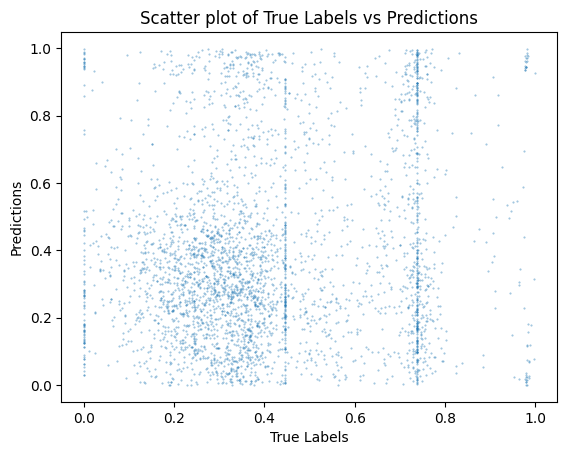

  0%|          | 1/500 [00:18<2:37:45, 18.97s/it]

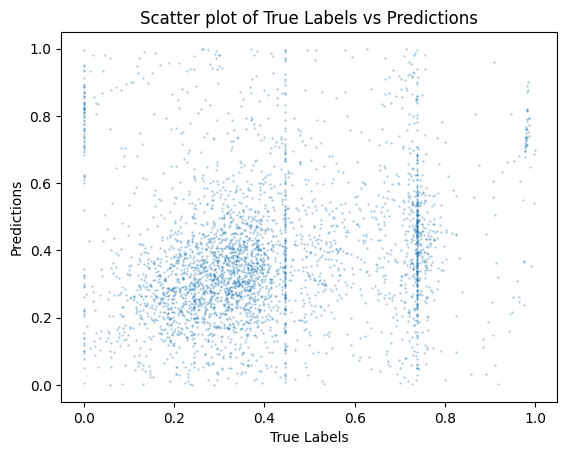

  0%|          | 2/500 [00:37<2:33:01, 18.44s/it]

Epoch [2/500] - Train Loss: 0.0586, Val Loss: 0.0467, Best Val: 0.0467


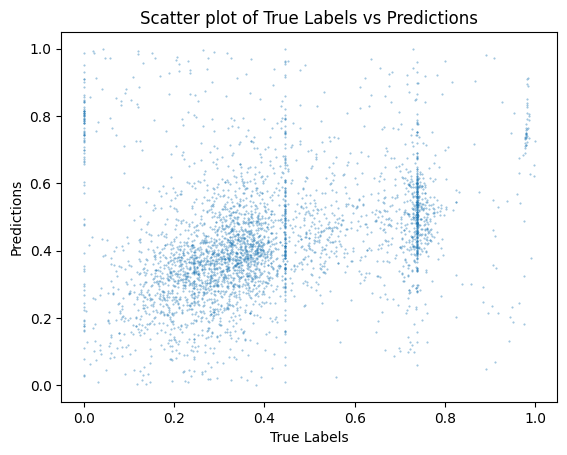

  1%|          | 3/500 [00:55<2:31:25, 18.28s/it]

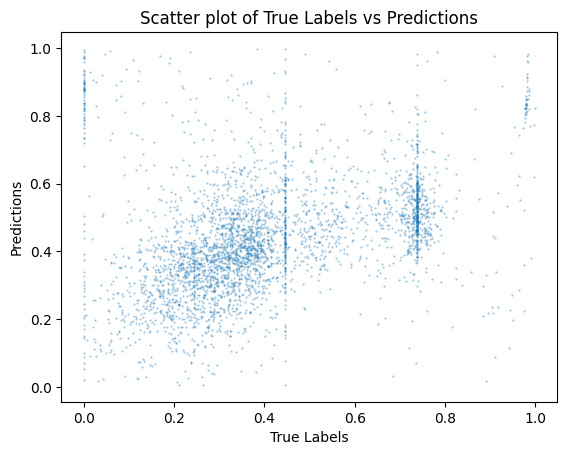

  1%|          | 4/500 [01:13<2:30:28, 18.20s/it]

Epoch [4/500] - Train Loss: 0.0338, Val Loss: 0.0316, Best Val: 0.0316


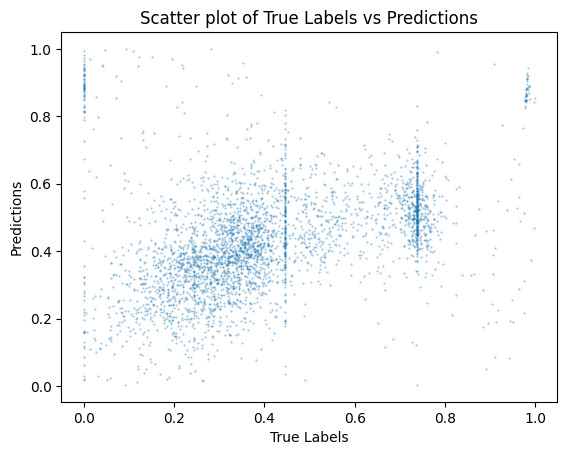

  1%|          | 5/500 [01:30<2:28:23, 17.99s/it]

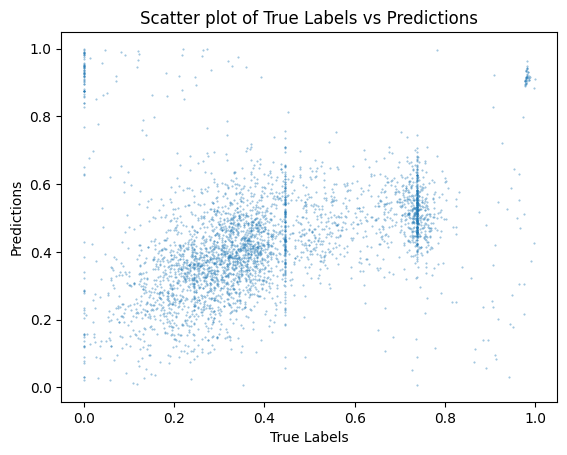

  1%|          | 6/500 [01:48<2:26:56, 17.85s/it]

Epoch [6/500] - Train Loss: 0.0299, Val Loss: 0.0276, Best Val: 0.0276


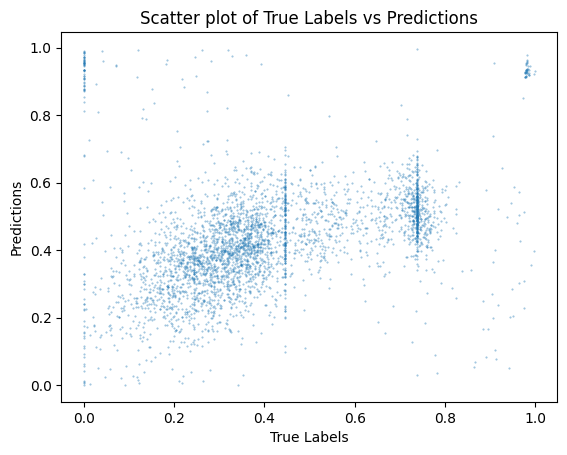

  1%|▏         | 7/500 [02:05<2:25:59, 17.77s/it]

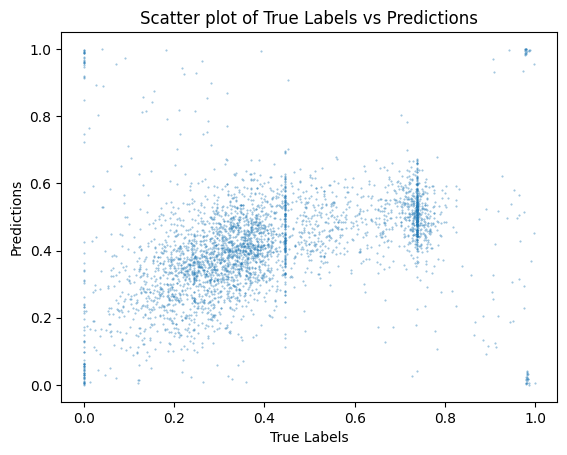

  2%|▏         | 8/500 [02:23<2:26:03, 17.81s/it]

Epoch [8/500] - Train Loss: 0.0289, Val Loss: 0.0274, Best Val: 0.0274


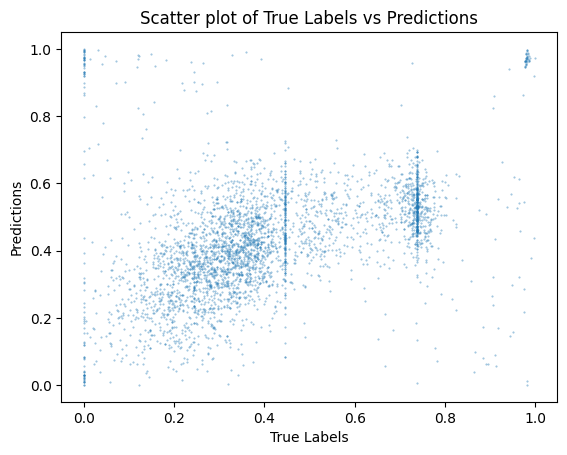

  2%|▏         | 9/500 [02:41<2:25:11, 17.74s/it]

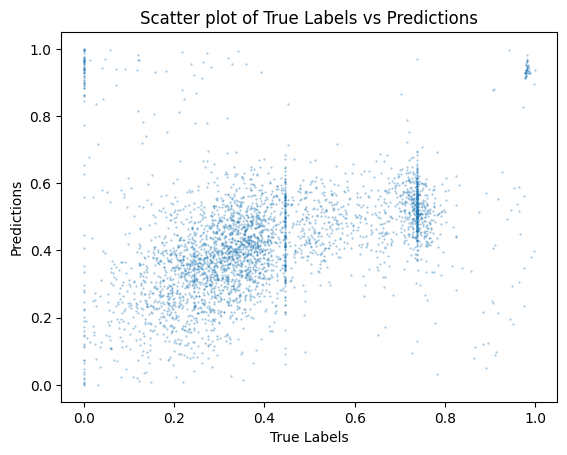

  2%|▏         | 10/500 [02:59<2:25:09, 17.77s/it]

Epoch [10/500] - Train Loss: 0.0286, Val Loss: 0.0272, Best Val: 0.0271


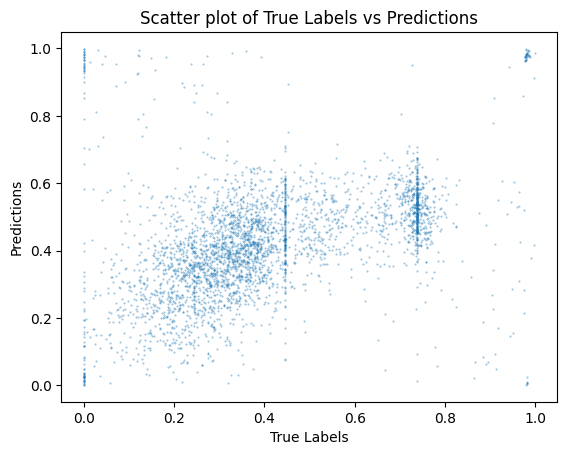

  2%|▏         | 11/500 [03:16<2:24:22, 17.71s/it]

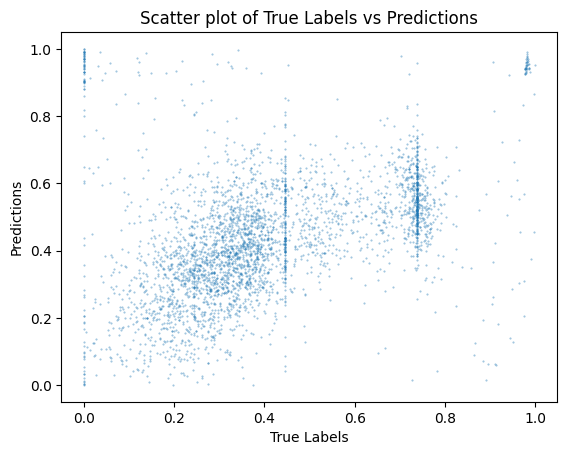

  2%|▏         | 12/500 [03:34<2:23:42, 17.67s/it]

Epoch [12/500] - Train Loss: 0.0284, Val Loss: 0.0277, Best Val: 0.0269


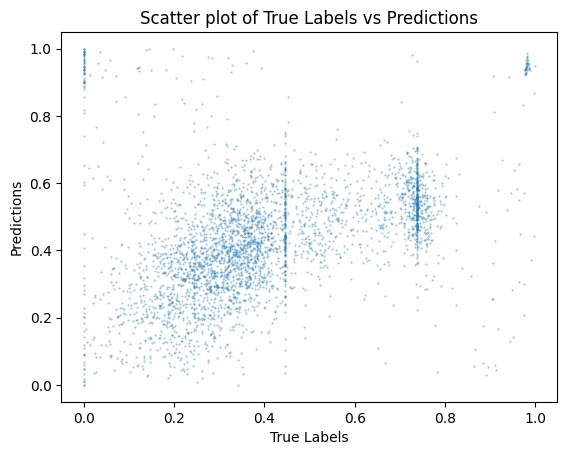

  3%|▎         | 13/500 [03:51<2:22:32, 17.56s/it]

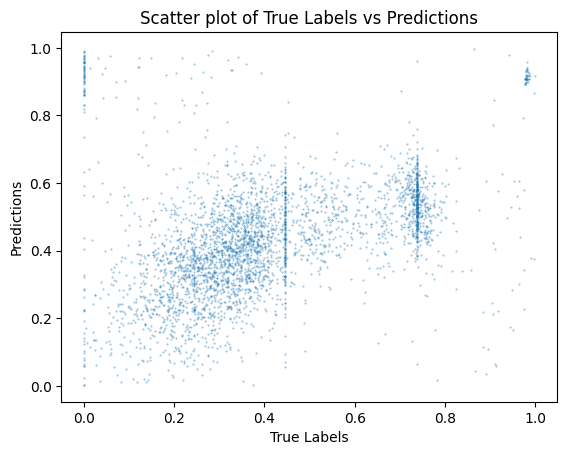

  3%|▎         | 14/500 [04:09<2:22:02, 17.54s/it]

Epoch [14/500] - Train Loss: 0.0283, Val Loss: 0.0273, Best Val: 0.0269


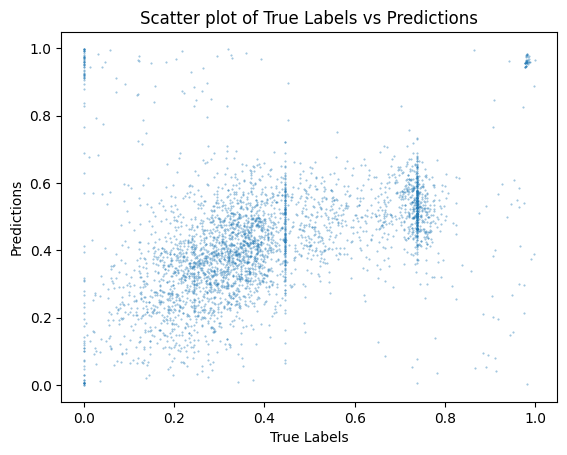

  3%|▎         | 15/500 [04:27<2:22:32, 17.63s/it]

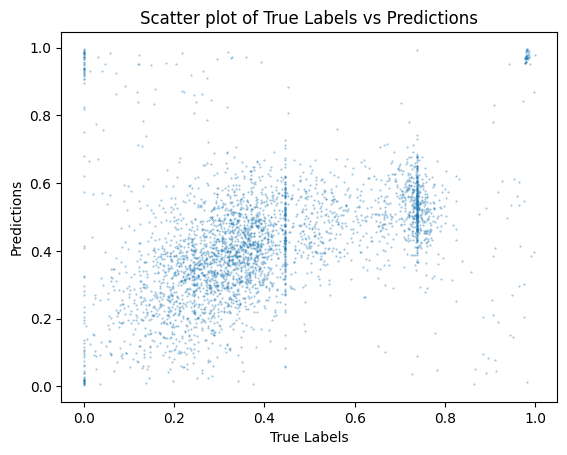

  3%|▎         | 16/500 [04:44<2:22:22, 17.65s/it]

Epoch [16/500] - Train Loss: 0.0282, Val Loss: 0.0269, Best Val: 0.0268


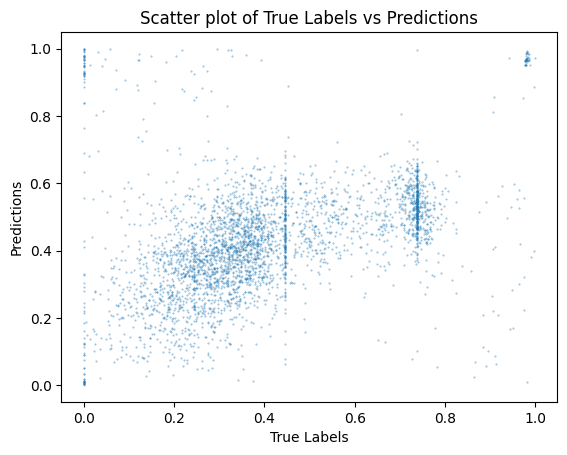

  3%|▎         | 17/500 [05:02<2:21:16, 17.55s/it]

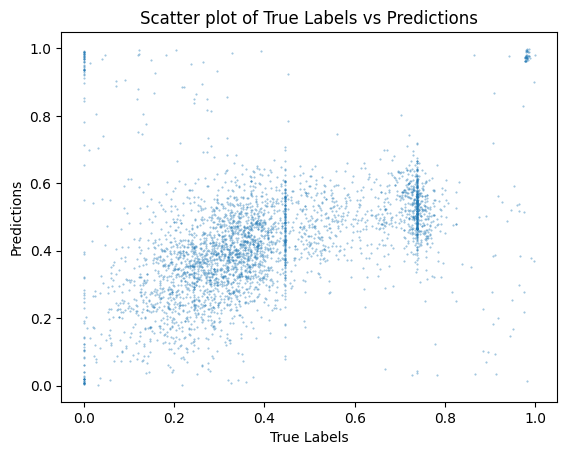

  4%|▎         | 18/500 [05:20<2:21:48, 17.65s/it]

Epoch [18/500] - Train Loss: 0.0282, Val Loss: 0.0267, Best Val: 0.0267


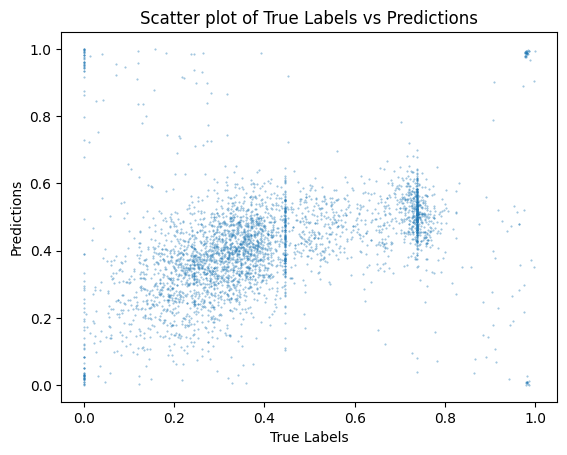

  4%|▍         | 19/500 [05:37<2:21:59, 17.71s/it]

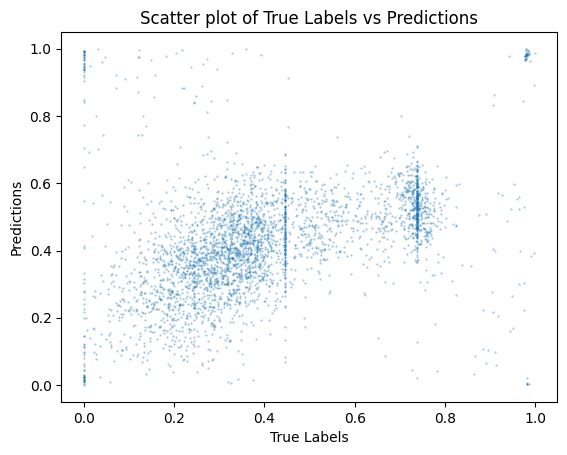

  4%|▍         | 20/500 [05:56<2:23:13, 17.90s/it]

Epoch [20/500] - Train Loss: 0.0280, Val Loss: 0.0267, Best Val: 0.0267


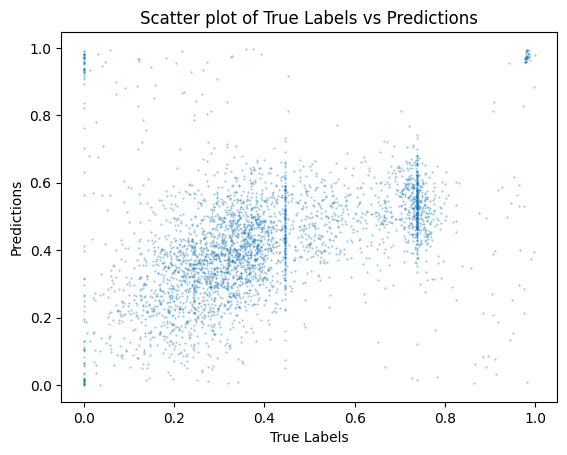

  4%|▍         | 21/500 [06:14<2:23:15, 17.95s/it]

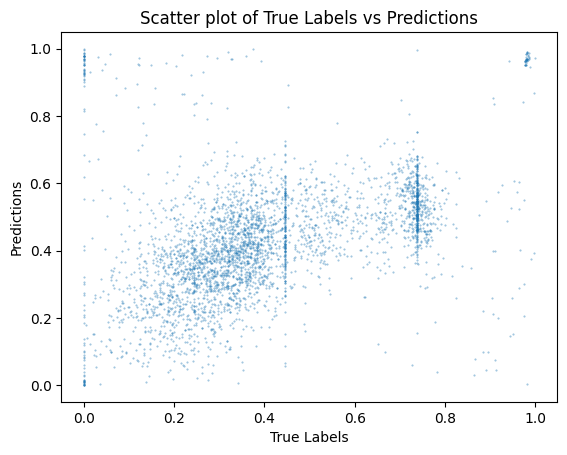

  4%|▍         | 22/500 [06:32<2:23:33, 18.02s/it]

Epoch [22/500] - Train Loss: 0.0281, Val Loss: 0.0268, Best Val: 0.0267


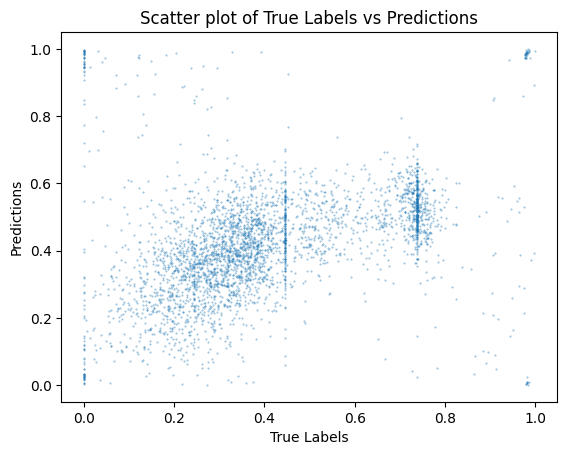

  5%|▍         | 23/500 [06:50<2:23:03, 18.00s/it]

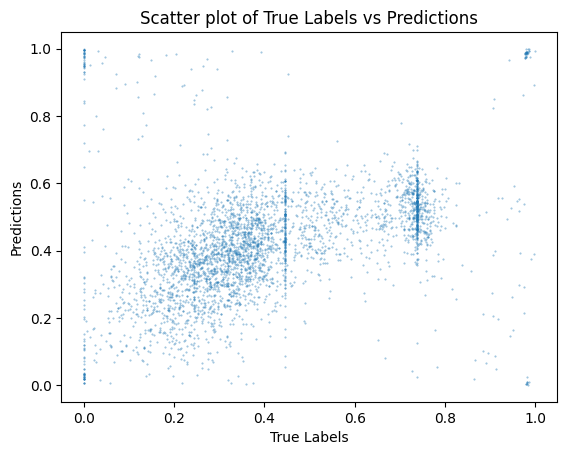

  5%|▍         | 24/500 [07:08<2:22:59, 18.02s/it]

Epoch [24/500] - Train Loss: 0.0280, Val Loss: 0.0267, Best Val: 0.0267


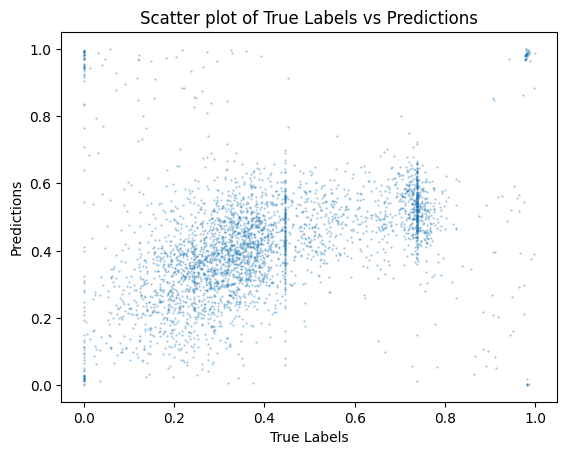

  5%|▌         | 25/500 [07:35<2:24:11, 18.21s/it]


KeyboardInterrupt: 

In [10]:
# Training history
history = {
    'train_loss': [],
    'val_loss': [],
}

best_val_loss = float('inf')
best_model_state = model.state_dict().copy()  # Initialize with current state
num_epochs = 500
print("Starting training...")
for epoch in tqdm(range(num_epochs)):
    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, _, _ = evaluate(model, val_loader, criterion, device)
    
    # Update scheduler
    scheduler.step(val_loss)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
    
    # Print progress
    if (epoch + 1) % 2 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - "
              f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, "
              f"Best Val: {best_val_loss:.4f}")

print(f"\nTraining completed! Best validation loss: {best_val_loss:.4f}")

# Load best model
model.load_state_dict(best_model_state)

In [28]:
model.load_state_dict(best_model_state)

<All keys matched successfully>

## 7. Plot Training History

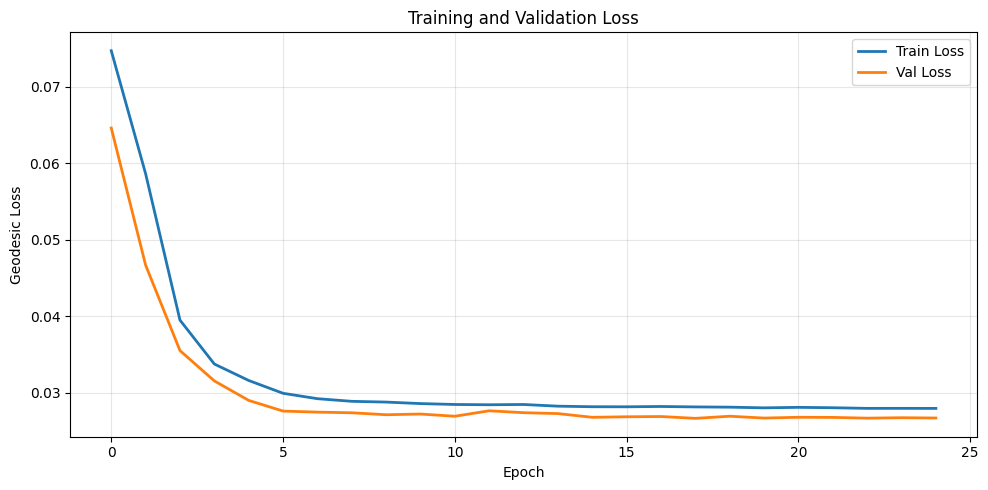

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss', linewidth=2)
plt.plot(history['val_loss'], label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Geodesic Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Evaluate on Test Set

geodesic_mae: 0.13674797102136702
geodesic_mse: 0.028535588577540447
geodesic_rmse: 0.16892480154654746
geodesic_r2: 0.40138564122664844
mae: None
mse: None
rmse: None
r2: None


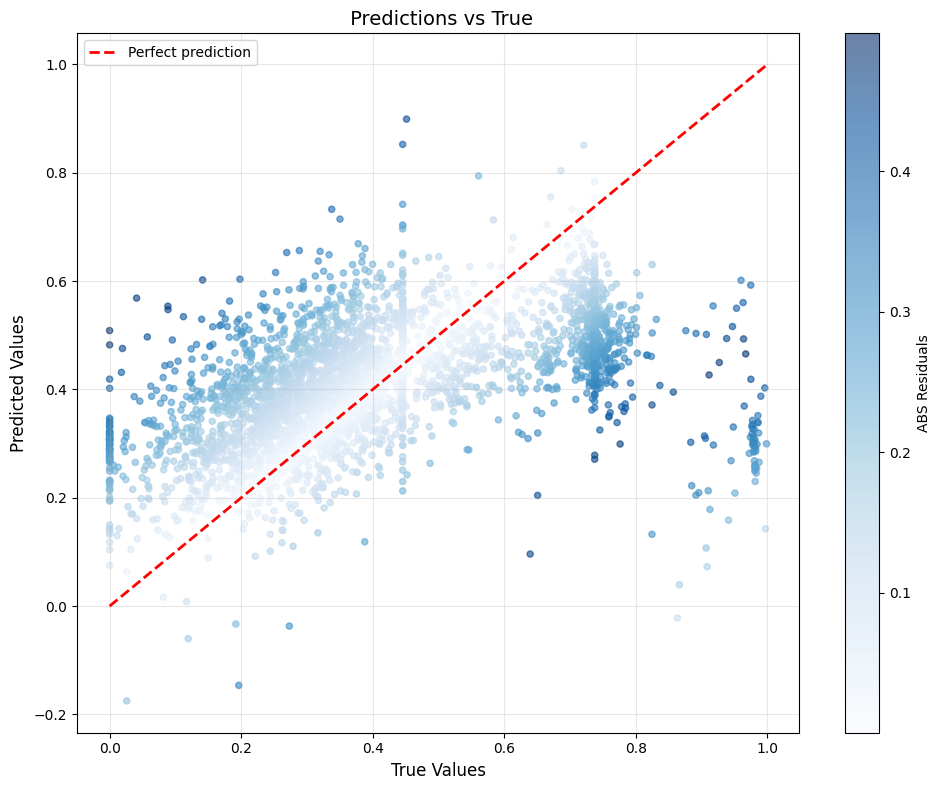

In [25]:
from src.evaluation.evaluator import Evaluator
from sklearn.linear_model import Ridge
model = Ridge(alpha=ridge_lambda)
model.fit(
    train_df.drop(columns=dataset.label_names).to_numpy(),
    train_df[dataset.label_names].to_numpy().ravel()
)
test_predictions = model.predict(
    val_df.drop(columns=dataset.label_names).to_numpy()
).reshape(-1, 1)
test_labels = val_df[dataset.label_names].to_numpy().reshape(-1, 1)
    

evaluator = Evaluator(projector=dataset.projector)
evaluator.config.plots_to_generate = ["scatter", "geodesic_residuals"]
# Evaluate on test set
# test_loss, test_predictions, test_labels = evaluate(model, test_loader, criterion, device)

results = evaluator.evaluate(test_labels, test_predictions)

for key, metric in results.metrics.to_dict().items():
    print(f"{key}: {metric}")

for key, plot in results.plots.items():
    plot.show()

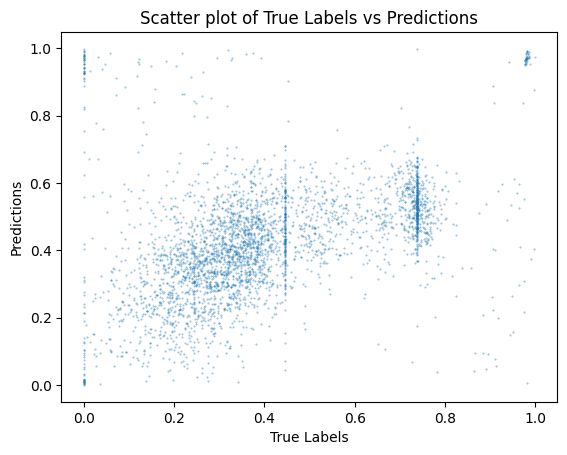

geodesic_mae: 0.1309155374765396
geodesic_mse: 0.026882905513048172
geodesic_rmse: 0.16396007292340464
geodesic_r2: 0.43605536222457886
mae: None
mse: None
rmse: None
r2: None


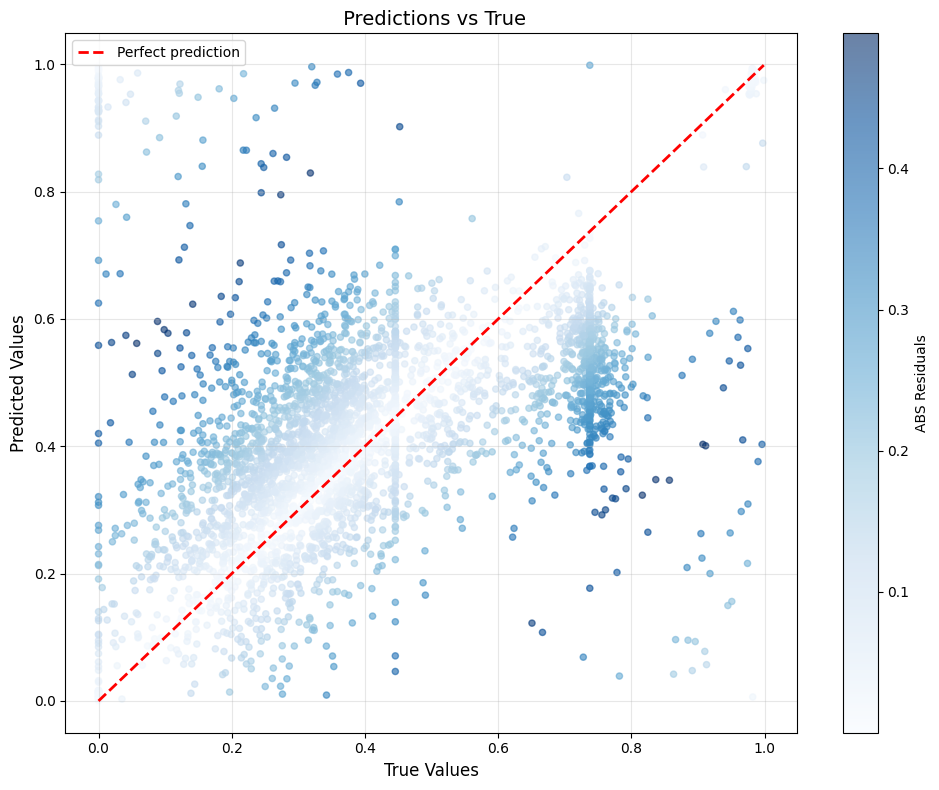

In [29]:
from src.evaluation.evaluator import Evaluator
from sklearn.linear_model import Ridge
# model = Ridge(alpha=ridge_lambda)
# model.fit(
#     test_df.drop(columns=dataset.label_names).to_numpy(),
#     test_df[dataset.label_names].to_numpy().ravel()
# )
# test_predictions = model.predict(
#     test_df.drop(columns=dataset.label_names).to_numpy()
# ).reshape(-1, 1)
# test_labels = test_df[dataset.label_names].to_numpy().reshape(-1, 1)


evaluator = Evaluator(projector=dataset.projector)
evaluator.config.plots_to_generate = ["scatter", "geodesic_residuals"]
# Evaluate on test set
test_loss, test_predictions, test_labels = evaluate(model, val_loader, criterion, device)

results = evaluator.evaluate(test_labels, test_predictions)

for key, metric in results.metrics.to_dict().items():
    print(f"{key}: {metric}")

for key, plot in results.plots.items():
    plot.show()

## 9. Visualize Predictions

In [ ]:
# Create visualization plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Scatter plot: Predictions vs True Labels
ax = axes[0, 0]
ax.scatter(label_normalized, pred_normalized, alpha=0.5, s=10)
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('True Phase (normalized)')
ax.set_ylabel('Predicted Phase (normalized)')
ax.set_title('Predictions vs True Labels')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Error distribution
ax = axes[0, 1]
ax.hist(geodesic_errors, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(0, color='r', linestyle='--', linewidth=2, label='Zero error')
ax.set_xlabel('Geodesic Error')
ax.set_ylabel('Frequency')
ax.set_title('Error Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Error vs True Phase
ax = axes[1, 0]
scatter = ax.scatter(label_normalized, geodesic_errors, c=np.abs(geodesic_errors), 
                    cmap='Reds', alpha=0.5, s=10)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('True Phase (normalized)')
ax.set_ylabel('Geodesic Error')
ax.set_title('Error vs True Phase')
plt.colorbar(scatter, ax=ax, label='Absolute Error')
ax.grid(True, alpha=0.3)

# 4. Phase space visualization using projector
ax = axes[1, 1]
# Sample subset for clearer visualization
n_samples = min(200, len(test_predictions))
indices = np.random.choice(len(test_predictions), n_samples, replace=False)

for i in indices[:50]:  # Plot a few examples
    true_val = float(label_normalized[i])
    pred_val = float(pred_normalized[i])
    
    # Plot on projector curve
    projector.plot(ax, named_points=[
        ("True", true_val),
        ("Pred", pred_val)
    ], show_legend=False)

ax.set_title('Phase Space: Predictions on FUCCI Curve (first 50 samples)')
ax.set_xlabel('mVenus-hGeminin(1/110)')
ax.set_ylabel('mCherry-hCdt1(30/120)')

plt.tight_layout()
plt.show()

## 10. Save Model

In [ ]:
# Save model checkpoint
save_dir = Path("/myhome/iris/checkpoints/linear_regression")
save_dir.mkdir(parents=True, exist_ok=True)

checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_loss': best_val_loss,
    'test_loss': test_loss,
    'test_mae': mae,
    'test_rmse': rmse,
    'input_dim': input_dim,
    'history': history,
}

save_path = save_dir / "linear_regression_geodesic.pt"
torch.save(checkpoint, save_path)
print(f"Model saved to: {save_path}")

## 11. Analyze Feature Importance

Model bias: 0.3702
Number of features: 28


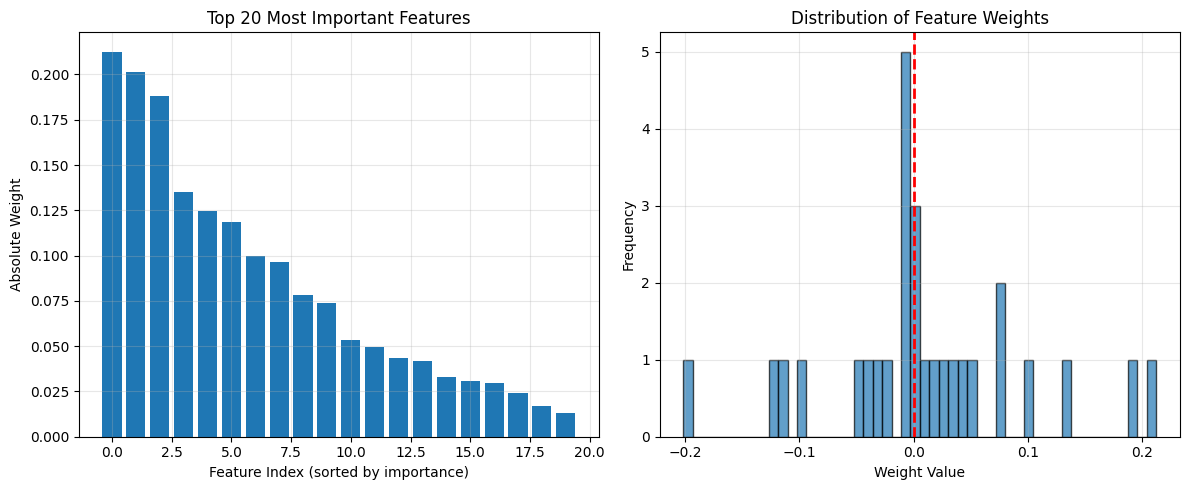


Top 10 most important features (by absolute weight):
1. Feature 27 log_nucleus_minor_axis_length: weight = 0.2126
2. Feature 20 log_cell_area: weight = -0.2016
3. Feature 1 cell_perimeter: weight = 0.1880
4. Feature 8 nucleus_area: weight = 0.1349
5. Feature 15 nucleus_minor_axis_length: weight = -0.1247
6. Feature 4 cell_solidity: weight = -0.1186
7. Feature 9 nucleus_perimeter: weight = 0.1000
8. Feature 21 log_cell_perimeter: weight = -0.0966
9. Feature 7 cell_minor_axis_length: weight = 0.0781
10. Feature 12 nucleus_solidity: weight = 0.0740


In [32]:
# Get learned weights
weights = model.linear.weight.detach().cpu().numpy().squeeze()
bias = model.linear.bias.detach().cpu().item()

print(f"Model bias: {bias:.4f}")
print(f"Number of features: {len(weights)}")

# Plot feature importance (absolute weights)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
feature_importance = np.abs(weights)
sorted_indices = np.argsort(feature_importance)[::-1]
top_k = 20
plt.bar(range(top_k), feature_importance[sorted_indices[:top_k]])
plt.xlabel('Feature Index (sorted by importance)')
plt.ylabel('Absolute Weight')
plt.title(f'Top {top_k} Most Important Features')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(weights, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Weight Value')
plt.ylabel('Frequency')
plt.title('Distribution of Feature Weights')
plt.axvline(0, color='r', linestyle='--', linewidth=2)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTop 10 most important features (by absolute weight):")
for i, idx in enumerate(sorted_indices[:10]):
    print(f"{i+1}. Feature {idx} {train_df.columns[idx]}: weight = {weights[idx]:.4f}")

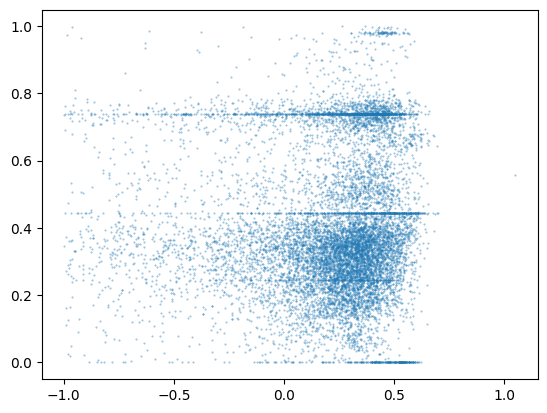

In [36]:
plt.scatter(train_df.iloc[:, 20][train_df.iloc[:, 20] > -1 ], train_df[dataset.label_names][train_df.iloc[:, 20] > -1 ], alpha=0.5, s=0.2)

In [37]:
train_df.iloc[:, 20]

3786    -0.345399
7065     0.536895
10898    0.384733
6637     0.488016
5258     0.517191
           ...   
2267     0.328847
15738   -2.603068
12713    0.327194
11194   -0.069420
6954    -0.068474
Name: log_cell_area, Length: 12588, dtype: float64